## Importação de Bibliotecas e Dados
Pretendo utilizar os dados disponibilizados no site https://www.atlasbrasil.org.br/. A ideia é criar um modelo de regrassão linear capaz de prever o IDHM de um estado ou cidade com base em três dados de entrada, sendo eles: IDHM Renda, IDHM Educação, IDHM Longevidade.

In [ ]:
import pandas as pd
import matplotlib as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv('data_cidades_rj.csv') # Dados referentes a cidades do estado do Rio de Janeiro (2020)


In [116]:
features = df[['IDHM Renda', 'IDHM Educação', 'IDHM Longevidade']]
target = df['IDHM']

In [117]:
print(df.shape)
features.head()

(92, 26)


,IDHM Renda,IDHM Educação,IDHM Longevidade
0,0.887,0.773,0.854
1,0.840,0.719,0.845
2,0.784,0.689,0.854
3,0.763,0.720,0.833
4,0.762,0.709,0.839


## Dataset Reduzido
O dataset utilizado contém apenas 92 municípios, o que é considerado pequeno para tarefas de Machine Learning. 
Para lidar com essa limitação, optei por reservar 20% dos dados para teste e 80% para treino — 
proporção que garante dados suficientes tanto para o modelo aprender quanto para ser avaliado.

Para validar essa escolha, implementei um script que testou todas as proporções de 0.1 a 0.8, 
comparando o MSE de cada uma.

In [118]:
modelo = LinearRegression()

In [119]:
menor_erro = 0
taxa_atual = 1/10
taxa_de_aumento = 1/10

for i in range(8):
    taxa_atual = round(taxa_atual, 1)
    print("Textando com a taxa: ", taxa_atual)
    taxa_atual += taxa_de_aumento

    feature_train, feature_test, target_train, target_test = train_test_split(features, target, test_size=taxa_atual, random_state=42)
    modelo.fit(feature_train, target_train)
    previsoes = modelo.predict(feature_test)
    erro = mean_squared_error(target_test, previsoes)

    if erro < menor_erro or menor_erro == 0:
        menor_erro = erro  
        melhor_taxa = taxa_atual  
        
print(f"Melhor taxa: {melhor_taxa} | Menor MSE: {menor_erro}")

Textando com a taxa:  0.1
Textando com a taxa:  0.2
Textando com a taxa:  0.3
Textando com a taxa:  0.4
Textando com a taxa:  0.5
Textando com a taxa:  0.6
Textando com a taxa:  0.7
Textando com a taxa:  0.8
Melhor taxa: 0.2 | Menor MSE: 3.911030928455818e-07


O resultado confirmou que **test_size=0.2** produziu o menor erro.

In [120]:
r2 = r2_score(target_test, previsoes)
mse = mean_squared_error(target_test, previsoes)
rmse = mse ** 0.5

print(f"R²:   {r2:.4f}")
print(f"MSE:  {mse:.8f}")
print(f"RMSE: {rmse:.4f}")

R²:   0.9992
MSE:  0.00000115
RMSE: 0.0011


## Avaliação do Modelo

Para avaliar a qualidade do modelo, utilizei três métricas:

- **R²**: mede o quanto o modelo explica a variação do IDHM. Quanto mais próximo de 1, melhor.
- **MSE**: erro quadrático médio — penaliza erros grandes.
- **RMSE**: raiz do MSE, mais fácil de interpretar pois está na mesma unidade do IDHM.

Text(0.5, 1.0, 'Real vs Previsto')

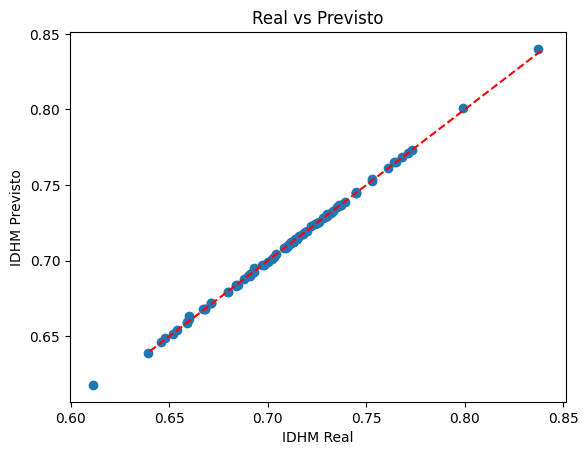

In [121]:
import matplotlib.pyplot as plt

plt.scatter(target_test, previsoes)
plt.plot([0.64, 0.84], [0.64, 0.84], color='red', linestyle='--')
plt.xlabel('IDHM Real')
plt.ylabel('IDHM Previsto')
plt.title('Real vs Previsto')

## Prova Final
Com o modelo treinado nos municípios do Rio de Janeiro, chegou o momento de testá-lo 
com dados que ele nunca viu: os 27 estados brasileiros. Esse teste revela se o modelo 
aprendeu padrões genuínos ou apenas memorizou os dados de treino.

In [ ]:
dados_estado = pd.read_csv('data.csv') # Dados referentes aos estados do Brasil (Dados de 2021)

features_ed = dados_estado[['IDHM Renda', 'IDHM Educação', 'IDHM Longevidade']]
target_ed = dados_estado['IDHM']

Text(0.5, 1.0, 'Real vs Previsto')

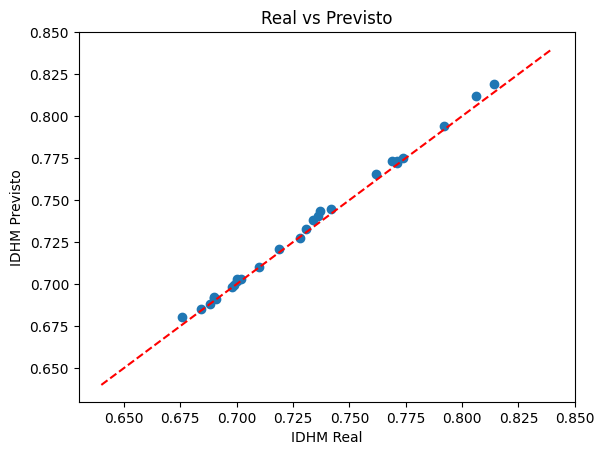

In [124]:
previsao = modelo.predict(features_ed)

plt.scatter(target_ed, previsao)
plt.plot([0.64, 0.84], [0.64, 0.84], color='red', linestyle='--')
plt.xlabel('IDHM Real')
plt.ylabel('IDHM Previsto')
plt.title('Real vs Previsto')

In [125]:
r2 = r2_score(target_ed, previsao)
mse = mean_squared_error(target_ed, previsao)
rmse = mse ** 0.5

print(f"R²:   {r2:.4f}")
print(f"MSE:  {mse:.8f}")
print(f"RMSE: {rmse:.4f}")

R²:   0.9942
MSE:  0.00000892
RMSE: 0.0030


## Conclusão
O modelo apresentou R² de 0.9942 e RMSE de 0.0030 nos dados dos estados brasileiros — 
resultados expressivos considerando que foi treinado apenas com municípios do Rio de Janeiro.

Isso indica que a relação entre as dimensões de Renda, Educação e Longevidade e o IDHM 
geral é consistente em diferentes contextos geográficos, validando a escolha da 
Regressão Linear para esse problema.

Os dados utilizados neste projeto foram obtidos através do 
[Atlas Brasil](http://www.atlasbrasil.org.br), plataforma do PNUD Brasil que 
disponibiliza indicadores de desenvolvimento humano para municípios e estados brasileiros.